In [532]:
import pandas as pd

df = pd.read_json("../../data/output_dataset.json")

df.head(5)

print(len(df))

2330


--- Thống kê số lượng vote trên mỗi datapoint ---
num_votes
1       3
2     142
3    2185
Name: count, dtype: int64

Chỉ số đồng thuận trung bình: 83.78%


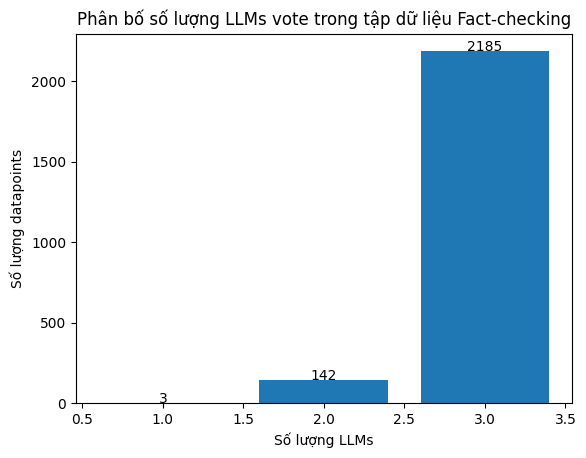

In [533]:
import matplotlib.pyplot as plt

df['num_votes'] = df['voter_details'].apply(lambda x: len(x) if isinstance(x, list) else 0)

# 2. Thống kê tổng quát số lượng datapoint theo số vote
vote_stats = df['num_votes'].value_counts().sort_index()

print("--- Thống kê số lượng vote trên mỗi datapoint ---")
print(vote_stats)

# 3. Xem các mẫu có ít hơn 3 vote (nếu có lỗi hệ thống gây thiếu vote)
low_vote_samples = df[df['num_votes'] < 3]

# 4. Tính tỉ lệ đồng thuận (Consensus Rate)
# Tách điểm số từ chuỗi "3/3" thành số thực để tính toán
df['score_val'] = df['consensus_score'].apply(lambda x: eval(x) if isinstance(x, str) else 0)
avg_consensus = df['score_val'].mean()

print(f"\nChỉ số đồng thuận trung bình: {avg_consensus:.2%}")


plt.bar(vote_stats.index, vote_stats.values)

# Thêm dòng này để hiện số trên đầu mỗi bar
for i, v in enumerate(vote_stats.values):
    plt.text(vote_stats.index[i], v + 0.5, str(v), ha='center')

plt.xlabel("Số lượng LLMs")
plt.ylabel("Số lượng datapoints")
plt.title("Phân bố số lượng LLMs vote trong tập dữ liệu Fact-checking")
plt.xticks(rotation=0)
plt.show()

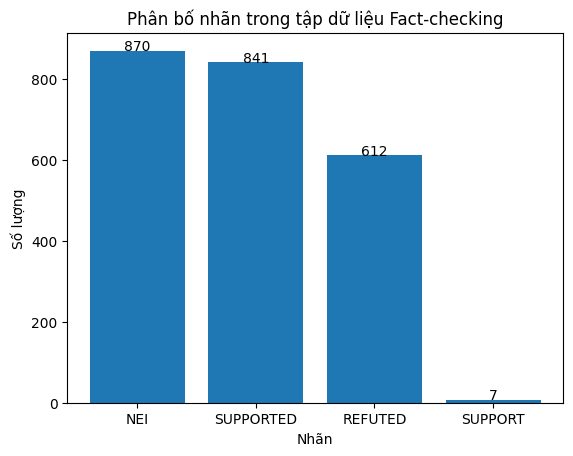

In [534]:
import matplotlib.pyplot as plt


counts = df['final_label'].value_counts()

plt.bar(counts.index, counts.values)

# Thêm dòng này để hiện số trên đầu mỗi bar
for i, v in enumerate(counts.values):
    plt.text(counts.index[i], v + 0.5, str(v), ha='center')

plt.xlabel("Nhãn")
plt.ylabel("Số lượng")
plt.title("Phân bố nhãn trong tập dữ liệu Fact-checking")
plt.xticks(rotation=0)
plt.show()

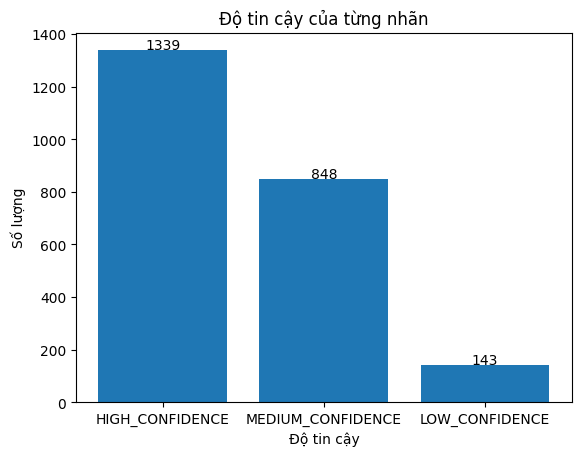

In [528]:
status_cnt = df['status'].value_counts()


# Thêm dòng này để hiện số trên đầu mỗi bar
for i, v in enumerate(status_cnt.values):
    plt.text(status_cnt.index[i], v + 3, str(v), ha='center')


plt.bar(status_cnt.index, status_cnt.values)    
plt.xlabel("Độ tin cậy")
plt.ylabel("Số lượng")
plt.title("Độ tin cậy của từng nhãn")
plt.show()

In [529]:
print(status_cnt)

status
HIGH_CONFIDENCE      1339
MEDIUM_CONFIDENCE     848
LOW_CONFIDENCE        143
Name: count, dtype: int64


In [530]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score

# Bước 1: Trích xuất vote của từng model thành các cột riêng biệt
def extract_model_votes(voter_details, model_name):
    for vote_info in voter_details:
        if vote_info['model'] == model_name:
            return vote_info['vote']
    return None

df['gpt_vote'] = df['voter_details'].apply(lambda x: extract_model_votes(x, 'openai/gpt-4o-mini'))
df['qwen_vote'] = df['voter_details'].apply(lambda x: extract_model_votes(x, 'qwen/qwen-2.5-72b-instruct'))
df['mistral_vote'] = df['voter_details'].apply(lambda x: extract_model_votes(x, 'mistralai/mistral-small-24b-instruct-2501'))

# Loại bỏ các dòng có giá trị None (nếu có model nào chưa vote dòng đó)
df_clean = df.dropna(subset=['gpt_vote', 'qwen_vote', 'mistral_vote'])

# Tính Kappa giữa từng cặp
kappa_gpt_qwen = cohen_kappa_score(df_clean['gpt_vote'], df_clean['qwen_vote'])
kappa_gpt_mistral = cohen_kappa_score(df_clean['gpt_vote'], df_clean['mistral_vote'])
kappa_qwen_mistral = cohen_kappa_score(df_clean['qwen_vote'], df_clean['mistral_vote'])

print(f"Kappa GPT vs Qwen: {kappa_gpt_qwen:.3f}")
print(f"Kappa GPT vs Mistral: {kappa_gpt_mistral:.3f}")
print(f"Kappa Qwen vs Mistral: {kappa_qwen_mistral:.3f}")

Kappa GPT vs Qwen: 0.579
Kappa GPT vs Mistral: 0.569
Kappa Qwen vs Mistral: 0.623


In [531]:
from statsmodels.stats.inter_rater import fleiss_kappa, aggregate_raters

# Chuyển đổi dữ liệu sang dạng ma trận đếm nhãn cho mỗi dòng
# Ví dụ: Dòng 1 có [SUPPORTED, SUPPORTED, REFUTED] -> thành [2, 1, 0] (tương ứng các nhãn)
voter_matrix = df_clean[['gpt_vote', 'qwen_vote', 'mistral_vote']].values
agg_data, categories = aggregate_raters(voter_matrix)

overall_kappa = fleiss_kappa(agg_data)
print(f"Fleiss' Kappa (Tổng thể 3 model): {overall_kappa:.3f}")

Fleiss' Kappa (Tổng thể 3 model): 0.588
